# Generating ECFPs of 1,024-bits

In [1]:
import numpy as np
import pandas as pd

# Generating fingerprints
from rdkit import Chem
from rdkit.Chem import AllChem

#PCA
from sklearn.decomposition import PCA

#Visualisation
import seaborn as sns
import matplotlib.pylab as plt

#Splitting data into train and test
from sklearn.model_selection import train_test_split

#Removing variance
from sklearn.feature_selection import VarianceThreshold

#Cross validation
from sklearn.model_selection import StratifiedKFold, cross_val_score
import statistics

# confusion matrix, AUC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

#Random Forest
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("final_df_smiles.csv", encoding = "ISO-8859-1")
df.head()

,Standardised_Smiles,Target
0,Oc1c(Cl)cc(Cl)cc1Sc1cc(Cl)cc(Cl)c1O,0
1,CCCCCC1C(=O)CCC1CC(=O)O,0
2,Cc1cc(=O)n(-c2ccccc2)n1C,0
3,O=C(C=CC=Cc1ccc2c(c1)OCO2)N1CCCCC1,0
4,O=c1ccc2cc(OC3OC(CO)C(O)C(O)C3O)c(O)cc2o1,0


In [3]:
# generating ECFPs (or morgan fps) with 1,024 bit length
morgan = []

for i in range (0, len(df)):
    mol = Chem.MolFromSmiles(df.iloc[i,0]) 
    fp = AllChem.GetMorganFingerprintAsBitVect(mol,2,nBits=1024)
    fp_list = np.unique(fp, return_inverse=True)[1].tolist()
    morgan.append(fp_list)

In [4]:
morgan = pd.DataFrame(data= morgan)
morgan = pd.concat([morgan, df.iloc[:, -1]], axis = 1)
display(morgan.head())
print(morgan.shape)

,0,1,2,3,4,5,6,7,8,9,...,1015,1016,1017,1018,1019,1020,1021,1022,1023,Target
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,1,0,1,0,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


(1430, 1025)


In [5]:
print("Inactive compounds: {}".format(morgan[(morgan['Target']==0)].shape[0]))
print("Active Compounds: {}".format(morgan[(morgan['Target']==1)].shape[0]))

Inactive compounds: 1126
Active Compounds: 304


In [6]:
X = morgan.iloc[:, : -1]
y = morgan.iloc[:, -1]

# Chemical Space Visualisation

In [7]:
pca = PCA(n_components=2)
print(X.shape)
res = pca.fit_transform(X)
print(res.shape)

(1430, 1024)
(1430, 2)


In [8]:
principal = pd.DataFrame(data = res, columns = ['PC 1', 'PC 2'])

finalPCA = pd.concat([principal,  morgan[['Target']]], axis = 1)
display(finalPCA.head())

,PC 1,PC 2,Target
0,-0.448598,-0.698810,0
1,-0.830554,0.879097,0
2,0.699555,-0.863350,0
3,0.513443,0.124680,0
4,0.009511,1.683063,0


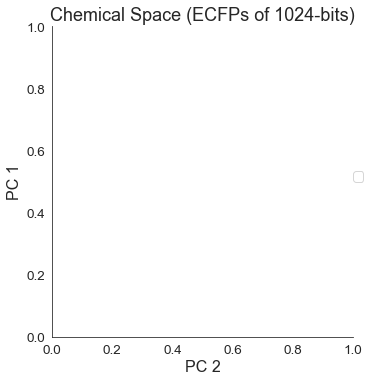

In [9]:
sns.set_style("white")


colours = 'silver', 'steelblue'
ax = sns.pairplot(x_vars=['PC 1'], y_vars=['PC 2'], 
             data=finalPCA, hue="Target", height=5, palette= colours)

ax._legend.remove()


plt.ylabel('PC 1',fontsize=16)
plt.xlabel('PC 2',fontsize=16)
plt.title('Chemical Space (ECFPs of 1024-bits)', fontsize= 18)
plt.xticks(fontsize=13.5)
plt.yticks(fontsize=13.5)

plt.legend(["Inactive (1126)", "Active (307)"], fontsize=13 ,  title_fontsize= 15 ,  
           bbox_to_anchor=(1, 0.5), loc= 3, borderaxespad=0., title = "")
    
plt.show()

# Data Pre-Processing

In [10]:
# splitting the database into 80% train and 20% test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 1)
print("X_train: {}".format(X_train.shape))
print("y_train: {}".format(y_train.shape))
print()
print("X_test: {}".format(X_test.shape))
print("y_test: {}".format(y_test.shape))

X_train: (1144, 1024)
y_train: (1144,)

X_test: (286, 1024)
y_test: (286,)


In [11]:
# removing features with low variance
def get_variance(df, threshold):
    sel = VarianceThreshold(threshold = (threshold))
    var = pd.DataFrame(data = sel.fit_transform(df))
    features = sel.get_support(indices = True) 
    var.columns = features
    return (var)

In [12]:
# creating three subdatabases which removes features with (i) 100% (ii) 95% and (iii) 90% constant values
X_var_100 = get_variance(X_train,1 *(1- 1))
X_var_95 = get_variance(X_train, 0.95 *(1- 0.95))
X_var_90 = get_variance(X_train, 0.90 *(1- 0.90))

display("X_var_100: {}".format(X_var_100.shape))
display("X_var_95: {}".format(X_var_95.shape))
display("X_var_90: {}".format(X_var_90.shape))

'X_var_100: (1144, 1024)'

'X_var_95: (1144, 137)'

'X_var_90: (1144, 55)'

# Feature Selection

In [20]:
# cross validation to compare performances of X_var_100, X_var_95 and X_var_90 on the train set
def cross_validation (num_splits, n_estimators, X, y, random_seed):
    
    sfk = StratifiedKFold(n_splits = num_splits, shuffle=True, random_state= random_seed)
    rf = RandomForestClassifier(n_estimators = n_estimators, random_state= random_seed) 
    rfc_cv_score = cross_val_score(rf, X, y, cv= sfk, scoring='roc_auc')

    return (statistics.median(rfc_cv_score), statistics.stdev(rfc_cv_score))

In [21]:
feature_selection = []

for subdatabase in (X_var_100, X_var_95, X_var_90):
    feature_selection.append(cross_validation (10, 100, subdatabase , y_train, 1))

In [26]:
feature_selection_df = pd.DataFrame(data = feature_selection, index=['X_var_100', 'X_var_95', 'X_var_90'])
feature_selection_df = feature_selection_df.round(decimals=3)*100
feature_selection_df.columns = ["Median AUC score (%)", "Standard Deviation"]
display(feature_selection_df)

,Median AUC score (%),Standard Deviation
X_var_100,75.1,6.5
X_var_95,76.9,4.6
X_var_90,76.1,5.4


# Model Performance on test set

In [27]:
# select features with best performance on train set, in this case X_var_95
best_features = X_var_95

# select the same features for the test set as X_var_95
colums_name= best_features.columns
X_test_features = X_test[colums_name[:]]
display(X_test_features.head())

,1,3,4,13,15,25,33,36,42,64,...,926,927,932,935,946,967,974,1009,1017,1019
951,1,0,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1059,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1269,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
236,0,0,0,0,0,0,0,0,0,1,...,1,0,0,1,0,0,0,0,0,0
942,0,0,0,0,1,0,1,0,0,1,...,1,0,0,1,0,0,0,0,0,1


In [34]:
# apply rf to obtain performance of best feature combination on test set
rf = RandomForestClassifier(n_estimators = 100, random_state= 1)
rf.fit(best_features, y_train)

#make predictions
y_score = rf.predict(X_test_features)
y_pred_proba = rf.predict_proba(X_test_features)[::,1]

# calculate performance matrices
print("=== Confusion Matrix ===")
CM = confusion_matrix(y_test, y_score)
print(CM)
print('\n')
print("=== Classification Report ===")
print(classification_report(y_test, y_score))
print('\n')
print("=== AUC Score ===")
print(roc_auc_score(y_test, y_pred_proba))

=== Confusion Matrix ===
[[225   9]
 [ 32  20]]


=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.96      0.92       234
           1       0.69      0.38      0.49        52

    accuracy                           0.86       286
   macro avg       0.78      0.67      0.71       286
weighted avg       0.84      0.86      0.84       286



=== AUC Score ===
0.7862836949375411


In [32]:
# apply rf algorithm to rank the features based on their importance
feature_imp = pd.Series(rf.feature_importances_,index=colums_name).sort_values(ascending=False)
feature_imp.head(10)

694     0.018266
147     0.016954
389     0.016936
80      0.016851
935     0.016042
656     0.015966
314     0.014879
33      0.014746
578     0.013639
1017    0.013317
dtype: float64